In [3]:
import os
import pandas as pd
import re
from pdbecif.mmcif_io import CifFileReader
from pathlib import Path


In [4]:
abs_paths = True
cfr = CifFileReader()
hist = []
for dir, _, files in os.walk('DDX_human_pdb'):
    cif_files = [f for f in files if f.endswith('.cif')]
    # print(len(cif_files))
    try:
        DDX_paralog, UNP_acc = os.path.split(dir)[-1].split('_')
    except:
        continue # root dir does not have '_'

    for file in cif_files:
        row = {}
        row['gene'] = DDX_paralog
        cif_pth = os.path.join(dir, file)
        if abs_paths:
            cif_data = str(Path(cif_pth).resolve())
        cif_obj = cfr.read(cif_pth)
        PDB_acc, cif_data = list(cif_obj.items())[0]
        row['PDB'] = PDB_acc
        row['UNP'] = UNP_acc
        struct_ref = cif_data['_struct_ref']
        struct_ref = {k: v if isinstance(v, list) else [v] for k,v in struct_ref.items()}
        struct_ref = pd.DataFrame(struct_ref)
        # Join Chain information on ID
        entity_poly = cif_data['_entity_poly']
        entity_poly = {k: v if isinstance(v, list) else [v] for k,v in entity_poly.items()}
        entity_poly = pd.DataFrame(entity_poly)
        entity_poly = entity_poly[['entity_id', 'pdbx_strand_id']]
        #entity_poly['PDB'] = PDB_acc
        struct_ref = pd.merge(struct_ref, entity_poly, 'left', left_on='id', right_on='entity_id')
        row['chains'] = len(struct_ref)
        row['path'] = os.path.join(dir, file)
        found_DDX = False
        for _, r in struct_ref.iterrows():
            AA_seq = re.sub(r'\s+', '', r['pdbx_seq_one_letter_code'])
            if 'DDX' in r['db_code'] or 'DEAD' in AA_seq or 'DX' in r['db_code'] or len(struct_ref) == 1:
                found_DDX = True
                row['id'] = r['id']
                row['chain'] = r['pdbx_strand_id']
        if not found_DDX:
            print(PDB_acc, DDX_paralog, "No DDX")

        hist.append(row)
DDX_df = pd.DataFrame(hist)

In [6]:
DDX_df

,gene,PDB,UNP,chains,path,id,chain
0,DDX48,2HXY,P38919,1,DDX_human_pdb/DDX48_P38919/2hxy.cif,1,"A,B,C,D"
1,DDX48,2HYI,P38919,5,DDX_human_pdb/DDX48_P38919/2hyi.cif,3,"B,H"
2,DDX2B,3BOR,Q14240,1,DDX_human_pdb/DDX2B_Q14240/3bor.cif,1,A
3,DDX39A,8IJU,O00148,1,DDX_human_pdb/DDX39A_O00148/8iju.cif,1,A
4,DDX5,3FE2,P17844,1,DDX_human_pdb/DDX5_P17844/3fe2.cif,1,"A,B"
5,DDX5,4A4D,P17844,1,DDX_human_pdb/DDX5_P17844/4a4d.cif,1,A
6,DDX17,6UV4,Q92841,2,DDX_human_pdb/DDX17_Q92841/6uv4.cif,1,A
7,DDX17,6UV2,Q92841,2,DDX_human_pdb/DDX17_Q92841/6uv2.cif,1,A
8,DDX21,6L5M,Q9NR30,1,DDX_human_pdb/DDX21_Q9NR30/6l5m.cif,1,"A,B,C,D,E"
9,DDX21,6L5L,Q9NR30,1,DDX_human_pdb/DDX21_Q9NR30/6l5l.cif,1,A


In [7]:
DDX_family = DDX_df.dropna()
sele = DDX_family.groupby('gene')['chains'].idxmin()
DDX_family = DDX_family.loc[sele]
DDX_family['chain'] = DDX_family['chain'].str.split(',')
DDX_family = DDX_family.explode('chain')

In [8]:
DDX_family['gene'].nunique()

27

In [10]:
DDX_family.to_csv('DDX_family.tsv',index=False, sep='\t')

In [9]:
DDX_family

,gene,PDB,UNP,chains,path,id,chain
30,DDX1,4XW3,Q92499,1,DDX_human_pdb/DDX1_Q92499/4xw3.cif,1,A
30,DDX1,4XW3,Q92499,1,DDX_human_pdb/DDX1_Q92499/4xw3.cif,1,B
16,DDX10,2PL3,Q13206,1,DDX_human_pdb/DDX10_Q13206/2pl3.cif,1,A
6,DDX17,6UV4,Q92841,2,DDX_human_pdb/DDX17_Q92841/6uv4.cif,1,A
10,DDX18,3LY5,Q9NVP1,1,DDX_human_pdb/DDX18_Q9NVP1/3ly5.cif,1,A
10,DDX18,3LY5,Q9NVP1,1,DDX_human_pdb/DDX18_Q9NVP1/3ly5.cif,1,B
26,DDX19B,3EWS,Q9UMR2,1,DDX_human_pdb/DDX19B_Q9UMR2/3ews.cif,1,A
26,DDX19B,3EWS,Q9UMR2,1,DDX_human_pdb/DDX19B_Q9UMR2/3ews.cif,1,B
21,DDX20,3B7G,Q9UHI6,1,DDX_human_pdb/DDX20_Q9UHI6/3b7g.cif,1,A
21,DDX20,3B7G,Q9UHI6,1,DDX_human_pdb/DDX20_Q9UHI6/3b7g.cif,1,B


# Most recent attempt to make family (10/25)

In [6]:
import json
import pandas as pd
with open('uniprotkb_xref_prosite_PS51192_AND_mode_2024_10_17.json') as f:
    DDX_UNP = json.load(f)
DDX_UNP_df = pd.DataFrame(DDX_UNP['results'])
DDX_UNP_df

,entryType,primaryAccession,secondaryAccessions,uniProtkbId,entryAudit,annotationScore,organism,proteinExistence,proteinDescription,genes,comments,features,keywords,references,uniProtKBCrossReferences,sequence,extraAttributes
0,UniProtKB reviewed (Swiss-Prot),O00148,"[B1Q2N1, Q8N5M0, Q9BVP6, Q9H5W0]",DX39A_HUMAN,"{'firstPublicDate': '2005-03-15', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'value': 'AT...,"[{'geneName': {'value': 'DDX39A'}, 'synonyms':...",[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Initiator methionine', 'location': ...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': 'CI...","[{'database': 'EMBL', 'id': 'U90426', 'propert...",{'value': 'MAEQDVENDLLDYDEEEEPQAPQESTPAPPKKDIK...,"{'countByCommentType': {'FUNCTION': 1, 'CATALY..."
1,UniProtKB reviewed (Swiss-Prot),O00571,"[A8K538, B4E3E8, O15536]",DDX3X_HUMAN,"{'firstPublicDate': '1998-07-15', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'value': 'AT...,"[{'geneName': {'value': 'DDX3X'}, 'synonyms': ...",[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Initiator methionine', 'location': ...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': 'CI...","[{'database': 'EMBL', 'id': 'U50553', 'propert...",{'value': 'MSHVAVENALGLDQQFAGLDLNSSDNQSGGSTASK...,"{'countByCommentType': {'FUNCTION': 6, 'CATALY..."
2,UniProtKB reviewed (Swiss-Prot),O14646,[Q17RZ3],CHD1_HUMAN,"{'firstPublicDate': '1998-07-15', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'value': 'Ch...,[{'geneName': {'evidences': [{'evidenceCode': ...,[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': '93...","[{'database': 'EMBL', 'id': 'AF006513', 'prope...",{'value': 'MNGHSDEESVRNSSGESSQSDDDSGSASGSGSGSS...,"{'countByCommentType': {'FUNCTION': 1, 'CATALY..."
3,UniProtKB reviewed (Swiss-Prot),O43143,[Q9NQT7],DHX15_HUMAN,"{'firstPublicDate': '1998-12-15', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'evidences':...,[{'geneName': {'evidences': [{'evidenceCode': ...,[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': '93...","[{'database': 'EMBL', 'id': 'AB001636', 'prope...",{'value': 'MSKRHRLDLGEDYPSGKKRAGTDGKDRDRDRDRED...,"{'countByCommentType': {'FUNCTION': 1, 'CATALY..."
4,UniProtKB reviewed (Swiss-Prot),O60231,"[O60322, Q5JP45, Q969X7, Q96QC1]",DHX16_HUMAN,"{'firstPublicDate': '1998-12-15', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'value': 'Pr...,"[{'geneName': {'value': 'DHX16'}, 'synonyms': ...",[{'texts': [{'evidences': [{'evidenceCode': 'E...,"[{'type': 'Chain', 'location': {'start': {'val...","[{'id': 'KW-0002', 'category': 'Technical term...","[{'referenceNumber': 1, 'citation': {'id': '95...","[{'database': 'EMBL', 'id': 'AB001601', 'prope...",{'value': 'MATPAGLERWVQDELHSVLGLSERHVAQFLIGTAQ...,"{'countByCommentType': {'FUNCTION': 1, 'CATALY..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,UniProtKB reviewed (Swiss-Prot),Q9ULG1,"[A6H8X4, Q9NTG6]",INO80_HUMAN,"{'firstPublicDate': '2006-09-05', 'lastAnnotat...",5.0,"{'scientificName': 'Homo sapiens', 'commonName...",1: Evidence at protein level,{'recommendedName': {'fullName': {'evidences':...,"[{'geneName': {'value': 'INO80'}, 'synonyms': ...",[{'texts': [{'eviden

In [7]:
DDX_df = []
accepted_genes = []
rejected_genes = []
for i,r in DDX_UNP_df.iterrows():
    if r['genes'] is None or isinstance(r['genes'], float) or len(r['genes']) == 0:
        continue
    
    gene_names = [r['genes'][0].get('geneName',{}).get('value')] + [item.get('value', None) for item in r['genes'][0].get('synonyms', {})]
    DDX_members = [name for name in gene_names if 'DDX' in name ]
    if len(DDX_members) > 0:
        row = {}
        row['UNP_acc'] = r['primaryAccession']
        row['genes'] = DDX_members
        DDX_df.append(row)
        accepted_genes.append(gene_names)
    else:
        rejected_genes.append(gene_names)
    # if i > 10:
    #     break
DDX_df = pd.DataFrame(DDX_df)
DDX_df = pd.merge(DDX_df, pd.read_csv("DDX_PROSITE_WITH_PDB.tsv", sep='\t')[['Entry','PDB']], left_on='UNP_acc', right_on='Entry')
DDX_df['PDB'] = DDX_df['PDB'].str.split(';')
DDX_df

,UNP_acc,genes,Entry,PDB
0,O00148,"[DDX39A, DDX39]",O00148,"[8IJU, ]"
1,O00571,"[DDX3X, DDX3]",O00571,"[2I4I, 2JGN, 3JRV, 4O2C, 4O2E, 4O2F, 4PX9, 4PX..."
2,O43143,[DDX15],O43143,"[5XDR, 6ID1, 6SH6, 6SH7, 8EJM, ]"
3,O60231,[DDX16],O60231,"[5Z56, 5Z57, 5Z58, 6FF7, 7DVQ, 7QTT, 8CH6, ]"
4,O95786,[DDX58],O95786,"[2LWD, 2LWE, 2QFB, 2QFD, 2RMJ, 2YKG, 3LRN, 3LR..."
5,P17844,[DDX5],P17844,"[3FE2, 4A4D, ]"
6,P26196,[DDX6],P26196,"[1VEC, 2WAX, 2WAY, 4CRW, 4CT4, 4CT5, 5ANR, 6F9..."
7,P38919,[DDX48],P38919,"[2HXY, 2HYI, 2J0Q, 2J0S, 2J0U, 2XB2, 3EX7, 4C9..."
8,P60842,[DDX2A],P60842,"[2G9N, 2ZU6, 3EIQ, 5ZBZ, 5ZC9, 6ZMW, 7PPZ, 7PQ..."
9,Q08211,[DDX9],Q08211,"[3LLM, 3VYX, 3VYY, 8SZP, ]"


### Selecting single PDB structure from list of linked structures

In [39]:
import requests
import os
from pdbecif.mmcif_io import CifFileReader
from tqdm import tqdm

cfr = CifFileReader()
DDX_PDB_df = []
for i, r in tqdm(DDX_df.iterrows(), total=len(DDX_df), desc="Downloading/Parsing CIF files"):
    DDX_name = r['genes'][0]
    for PDB_acc in r['PDB']:
        if PDB_acc == '':
            continue
        request_url = f'https://files.rcsb.org/download/{PDB_acc}.cif'
        cif_save_path = f'DDX_human_pdb/DDX_PROSITE_SEARCH/{DDX_name}/{PDB_acc}.cif'
        os.makedirs(os.path.dirname(cif_save_path), exist_ok=True)
        if not os.path.exists(cif_save_path):
            # Donload if you don't have the CIF
            response = requests.get(request_url)
            if response.status_code == 200:
                with open(cif_save_path, 'wb') as file:
                    file.write(response.content)
            else:
                print(PDB_acc)
        # Analyze the cif to see if it is a good canidate
        UNP_acc = r['UNP_acc']
        row = {'UNP_acc':UNP_acc, 'gene':DDX_name, 'PDB_acc':PDB_acc, 'path':cif_save_path}
        cif_obj = cfr.read(cif_save_path)
        
        ent_poly_df = list(cif_obj.values())[0]['_entity_poly']
        for key in ent_poly_df: # make sure it's a dataframe if there is only one polymer 
            if not isinstance(ent_poly_df[key], list):
                ent_poly_df[key] = [ent_poly_df[key]]
        ent_poly_df = pd.DataFrame(ent_poly_df)

        struct_ref_df = list(cif_obj.values())[0]['_struct_ref_seq']
        for key in struct_ref_df: # make sure it's a dataframe if there is only one polymer 
            if not isinstance(struct_ref_df[key], list):
                struct_ref_df[key] = [struct_ref_df[key]]
        struct_ref_df = pd.DataFrame(struct_ref_df)

        struct_ref_r_df = list(cif_obj.values())[0]['_struct_ref']
        for key in struct_ref_r_df: # make sure it's a dataframe if there is only one polymer 
            if not isinstance(struct_ref_r_df[key], list):
                struct_ref_r_df[key] = [struct_ref_r_df[key]]
        struct_ref_r_df = pd.DataFrame(struct_ref_r_df)
        struct_ref_r_df = struct_ref_r_df.drop(columns=['pdbx_db_accession'])  # Example
        struct_ref_df = pd.merge(struct_ref_df, struct_ref_r_df, left_on = 'ref_id', right_on='id')
        # print(struct_ref_df.columns)

        PDB_acc_col = 'pdbx_db_accession'
        row['UNP_matches']=sum(struct_ref_df[PDB_acc_col]==UNP_acc)
        row['matching_chains'] = list(struct_ref_df[struct_ref_df[PDB_acc_col]==UNP_acc]['pdbx_strand_id'])
        row['num_chains'] = len(ent_poly_df)
        # try:
        row['seq'] = list(struct_ref_df[struct_ref_df[PDB_acc_col]==UNP_acc]['pdbx_seq_one_letter_code'])
        row['gene_len'] = list((struct_ref_df[struct_ref_df[PDB_acc_col]==UNP_acc]['pdbx_auth_seq_align_end'].astype(int) - struct_ref_df[struct_ref_df['pdbx_db_accession']==UNP_acc]['pdbx_auth_seq_align_beg'].astype(int)))#.iloc[0]
        # except:
        #     continue # don't save the result if it doesn't have a match for the UNP entry

        #row['chains'] = len(ent_poly_df)
        DDX_PDB_df.append(row)
    # break
DDX_PDB_df = pd.DataFrame(DDX_PDB_df)
DDX_PDB_df = DDX_PDB_df[DDX_PDB_df['UNP_matches'] > 0]
DDX_PDB_df

Downloading/Parsing CIF files:   0%|          | 0/37 [00:00<?, ?it/s]

Downloading/Parsing CIF files: 100%|██████████| 37/37 [01:23<00:00,  2.24s/it]


,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains,seq,gene_len
0,O00148,DDX39A,8IJU,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX39A/8IJU.cif,1,[A],1,[HSSGFRDFLLKPELLRAIVDCGFEHPSEVQHECIPQAILGMDVLC...,[385]
1,O00571,DDX3X,2I4I,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/2I4I.cif,1,[A],1,[?],[414]
2,O00571,DDX3X,2JGN,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/2JGN.cif,3,"[A, B, C]",1,"[?, ?, ?]","[171, 171, 171]"
3,O00571,DDX3X,3JRV,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/3JRV.cif,3,"[C, D, E]",2,"[SFGSRSDSRGKSSFFSDRGS, SFGSRSDSRGKSSFFSDRGS, S...","[19, 19, 19]"
4,O00571,DDX3X,4O2C,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/4O2C.cif,1,[C],3,[SHVAVENAL],[8]
...,...,...,...,...,...,...,...,...,...
234,Q9UMR2,DDX19B,3G0H,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/3G0H.cif,1,[A],2,[EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELR...,[421]
235,Q9UMR2,DDX19B,6B4I,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4I.cif,2,"[E, F]",3,[EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELR...,"[425, 425]"
236,Q9UMR2,DDX19B,6B4J,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4J.cif,2,"[E, F]",3,[EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELR...,"[425, 425]"
237,Q9UMR2,DDX19B,6B4K,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4K.cif,2,"[A, B]",1,[EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELR...,"[425, 425]"


In [53]:
test_df = DDX_PDB_df.explode(['matching_chains', 'seq', 'gene_len'])
test_df = test_df[test_df['seq'] != '?']
test_df['seq'] = test_df['seq'].str.replace(r'\s+', '', regex=True)
test_df['has_DEAD'] = test_df['seq'].str.contains('DEAD')
test_df

,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains,seq,gene_len,has_DEAD
0,O00148,DDX39A,8IJU,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX39A/8IJU.cif,1,A,1,HSSGFRDFLLKPELLRAIVDCGFEHPSEVQHECIPQAILGMDVLCQ...,385,False
3,O00571,DDX3X,3JRV,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/3JRV.cif,3,C,2,SFGSRSDSRGKSSFFSDRGS,19,False
3,O00571,DDX3X,3JRV,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/3JRV.cif,3,D,2,SFGSRSDSRGKSSFFSDRGS,19,False
3,O00571,DDX3X,3JRV,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/3JRV.cif,3,E,2,SFGSRSDSRGKSSFFSDRGS,19,False
4,O00571,DDX3X,4O2C,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/4O2C.cif,1,C,3,SHVAVENAL,8,False
...,...,...,...,...,...,...,...,...,...,...
236,Q9UMR2,DDX19B,6B4J,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4J.cif,2,E,3,EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELRL...,425,True
236,Q9UMR2,DDX19B,6B4J,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4J.cif,2,F,3,EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELRL...,425,True
237,Q9UMR2,DDX19B,6B4K,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4K.cif,2,A,1,EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELRL...,425,True
237,Q9UMR2,DDX19B,6B4K,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4K.cif,2,B,1,EDRAAQSLLNKLIRSNLVDNTNQVEVLQRDPNSPLYSVKSFEELRL...,425,True


<Axes: ylabel='Frequency'>

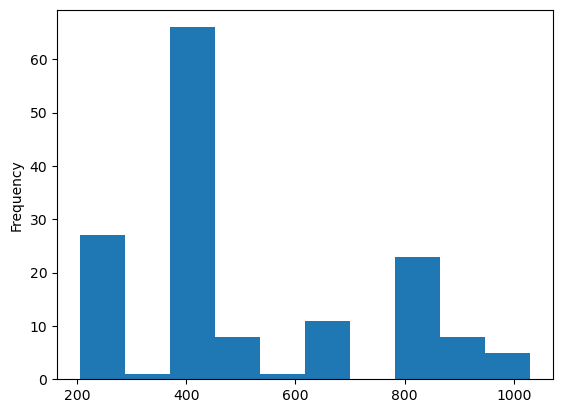

In [54]:
test_df[test_df['has_DEAD']]['gene_len'].plot.hist()

In [56]:
test_df.groupby('gene')['has_DEAD'].any().mean()

0.5555555555555556

In [92]:
explode_df = DDX_PDB_df.explode(['matching_chains','gene_len'])
explode_df

,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains,gene_len
0,O00148,DDX39A,8IJU,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX39A/8IJU.cif,1,A,1,385
1,O00571,DDX3X,2I4I,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/2I4I.cif,1,A,1,414
2,O00571,DDX3X,2JGN,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/2JGN.cif,3,A,1,171
2,O00571,DDX3X,2JGN,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/2JGN.cif,3,B,1,171
2,O00571,DDX3X,2JGN,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX3X/2JGN.cif,3,C,1,171
...,...,...,...,...,...,...,...,...
236,Q9UMR2,DDX19B,6B4J,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4J.cif,2,E,3,425
236,Q9UMR2,DDX19B,6B4J,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4J.cif,2,F,3,425
237,Q9UMR2,DDX19B,6B4K,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4K.cif,2,A,1,425
237,Q9UMR2,DDX19B,6B4K,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/6B4K.cif,2,B,1,425


<Axes: ylabel='Frequency'>

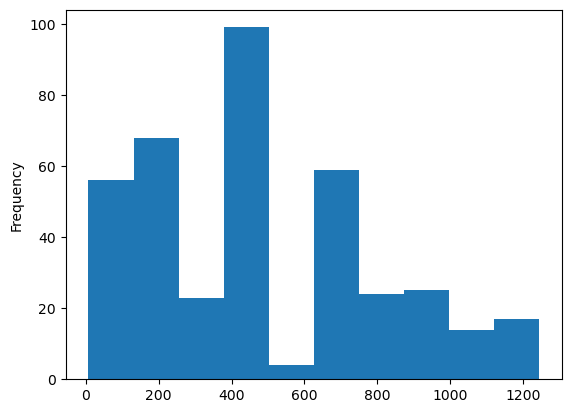

In [95]:
explode_df['gene_len'].plot.hist()

In [96]:
selected_idx = DDX_PDB_df.groupby('gene')['matching_chains'].idxmin()
DDX_PDB_single_df = DDX_PDB_df.loc[selected_idx]
DDX_PDB_single_df['chain'] = DDX_PDB_single_df['matching_chains'].apply(lambda x:x[0])
DDX_PDB_single_df

,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains,gene_len,chain
166,Q92499,DDX1,8TBX,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX1/8TBX.cif,2,"[A, A]",1,"[278, 388]",A
116,Q13206,DDX10,2PL3,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX10/2PL3.cif,1,[A],1,[233],A
140,Q15477,DDX13,7QDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDR.cif,1,[A],3,[1245],A
16,O43143,DDX15,5XDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX15/5XDR.cif,1,[A],1,[685],A
26,O60231,DDX16,7QTT,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX16/7QTT.cif,1,[N],37,[1040],N
172,Q92841,DDX17,6UV2,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX17/6UV2.cif,1,[A],2,[445],A
210,Q9NVP1,DDX18,3LY5,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX18/3LY5.cif,2,"[A, B]",1,"[238, 238]",A
234,Q9UMR2,DDX19B,3G0H,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/3G0H.cif,1,[A],2,[421],A
221,Q9UHI6,DDX20,2OXC,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX20/2OXC.cif,2,"[A, B]",1,"[227, 227]",A
204,Q9NR30,DDX21,2M3D,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX21/2M3D.cif,1,[A],1,[93],A


In [99]:
DDX_PDB_df[DDX_PDB_df['gene'] == 'DDX13']

,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains,gene_len
140,Q15477,DDX13,7QDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDR.cif,1,[A],3,[1245]
141,Q15477,DDX13,7QDS,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDS.cif,1,[A],3,[1245]
142,Q15477,DDX13,7QDY,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDY.cif,1,[A],4,[1245]
143,Q15477,DDX13,7QDZ,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDZ.cif,1,[A],4,[1245]
144,Q15477,DDX13,7QE0,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QE0.cif,1,[A],2,[1245]


In [97]:
DDX_PDB_single_df

,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains,gene_len,chain
166,Q92499,DDX1,8TBX,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX1/8TBX.cif,2,"[A, A]",1,"[278, 388]",A
116,Q13206,DDX10,2PL3,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX10/2PL3.cif,1,[A],1,[233],A
140,Q15477,DDX13,7QDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDR.cif,1,[A],3,[1245],A
16,O43143,DDX15,5XDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX15/5XDR.cif,1,[A],1,[685],A
26,O60231,DDX16,7QTT,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX16/7QTT.cif,1,[N],37,[1040],N
172,Q92841,DDX17,6UV2,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX17/6UV2.cif,1,[A],2,[445],A
210,Q9NVP1,DDX18,3LY5,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX18/3LY5.cif,2,"[A, B]",1,"[238, 238]",A
234,Q9UMR2,DDX19B,3G0H,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/3G0H.cif,1,[A],2,[421],A
221,Q9UHI6,DDX20,2OXC,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX20/2OXC.cif,2,"[A, B]",1,"[227, 227]",A
204,Q9NR30,DDX21,2M3D,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX21/2M3D.cif,1,[A],1,[93],A


In [84]:
DDX_PDB_df[DDX_PDB_df['gene'] == 'DDX46']

,UNP_acc,gene,PDB_acc,path,UNP_matches,matching_chains,num_chains
146,Q7L014,DDX46,6Y50,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX46/6Y50.cif,1,[p],9
147,Q7L014,DDX46,6Y53,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX46/6Y53.cif,1,[p],19
148,Q7L014,DDX46,6Y5Q,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX46/6Y5Q.cif,1,[p],22
150,Q7L014,DDX46,7Q3L,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX46/7Q3L.cif,1,[p],9
151,Q7L014,DDX46,7VPX,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX46/7VPX.cif,1,[E],28


In [98]:
export_df = DDX_PDB_single_df.copy()
export_df = export_df[['PDB_acc', 'path', 'chain', 'gene_len']]
#export_df.to_csv('DDX_family_full.tsv', sep='\t')
export_df

,PDB_acc,path,chain,gene_len
166,8TBX,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX1/8TBX.cif,A,"[278, 388]"
116,2PL3,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX10/2PL3.cif,A,[233]
140,7QDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX13/7QDR.cif,A,[1245]
16,5XDR,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX15/5XDR.cif,A,[685]
26,7QTT,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX16/7QTT.cif,N,[1040]
172,6UV2,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX17/6UV2.cif,A,[445]
210,3LY5,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX18/3LY5.cif,A,"[238, 238]"
234,3G0H,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX19B/3G0H.cif,A,[421]
221,2OXC,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX20/2OXC.cif,A,"[227, 227]"
204,2M3D,DDX_human_pdb/DDX_PROSITE_SEARCH/DDX21/2M3D.cif,A,[93]
